<a href="https://colab.research.google.com/github/Nguyencaoquochuy/Nguy-n-Cao-Qu-c-Huy-CS441V-Data-Visualization-/blob/main/DV0101EN_Exercise_Introduction_to_Matplotlib_and_Line_Plots_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np  # useful for many scientific computing in Python
import pandas as pd # primary data structure library

In [ ]:
# install xlrd
!pip install xlrd

print('xlrd installed!')

xlrd installed!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df_can = pd.read_excel('/content/drive/MyDrive/Canada (1).xlsx',
                       sheet_name='Canada by Citizenship',
                       skiprows=range(20))

print ('Data read into a pandas dataframe!')

Data read into a pandas dataframe!


# **Khi xem dữ liệu nhập cư vào canada của các quốc gia trên toàn thế giới thì có giả thuyết:**
Thống kê nhập cư tăng/giảm theo các cú sốc chính trị – kinh tế – chiến tranh hơn là tăng đều theo năm .



# Đây là biểu đồ nhập cư vào Canada từ 1980-2013

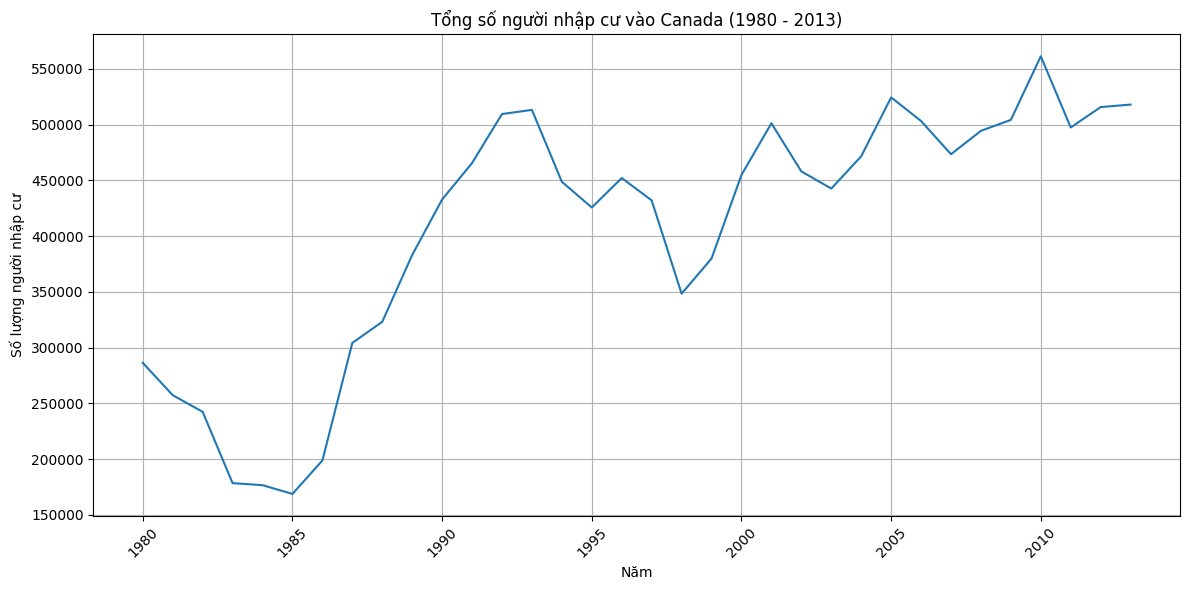

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Make a copy to avoid modifying the original DataFrame directly for this step
df_can_plot = df_can.copy()

# Identify columns that represent years (assuming they are integers or strings of 4 digits)
years = [col for col in df_can_plot.columns if isinstance(col, int) or (isinstance(col, str) and col.isdigit() and len(col) == 4)]
years = sorted([int(year) for year in years])

# Select only the year columns for summation
df_years_data = df_can_plot[years]

# Sum immigration for each year across all countries
df_total_yearly = pd.DataFrame(df_years_data.sum(axis=0))
df_total_yearly.index.name = 'Year'
df_total_yearly.columns = ['Total Immigration']

# Reset index to make 'Year' a column for plotting
df_total_yearly.reset_index(inplace=True)

# Convert 'Year' to integer type if it's not already
df_total_yearly['Year'] = df_total_yearly['Year'].astype(int)

# Plot the total immigration over the years
plt.figure(figsize=(12, 6))
plt.plot(df_total_yearly['Year'], df_total_yearly['Total Immigration'])
plt.title('Tổng số người nhập cư vào Canada ({} - {})'.format(years[0], years[-1]))
plt.xlabel('Năm')
plt.ylabel('Số lượng người nhập cư')
plt.grid(True)
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

# **1. Nhận biết nhập cư tăng/giảm theo các cú sốc chính trị – kinh tế – chiến tranh từ số liệu qua các năm .**

Bảng số liệu nhập cư theo từng khu vực qua các năm.

In [39]:
display(df_area_yearly_melted)

,AreaName,Năm,Tổng số người nhập cư
0,Africa,1980,3951
1,Asia,1980,31025
2,Europe,1980,39760
3,Latin America and the Caribbean,1980,13081
4,Northern America,1980,9378
...,...,...,...
233,Europe,2013,28691
234,Latin America and the Caribbean,2013,24950
235,Northern America,2013,8503
236,Oceania,2013,1775


Biểu đồ dân nhập cư của các khu vực theo các năm

Sử dụng biểu đồ đường vì dễ nhìn nhận rõ về khoảng tăng giảm của số liệu , qua đó có thể ước tính được xu hướng.Từ đó có thể dễ dàng nhận biết chuỗi các sự kiện.

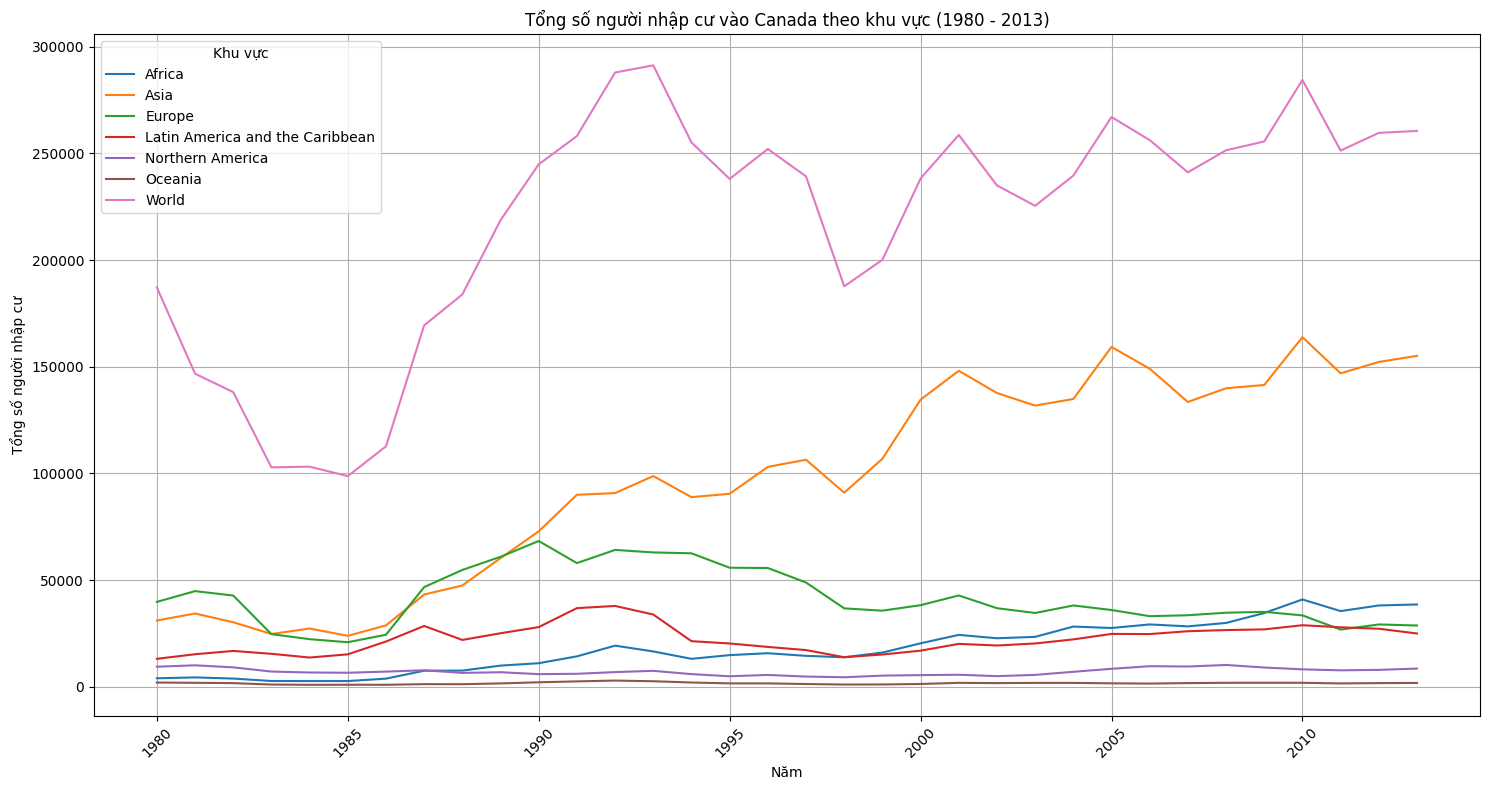

In [36]:
import matplotlib.pyplot as plt

# Create the line plot
plt.figure(figsize=(15, 8))

# Get unique area names
area_names = df_area_yearly_melted['AreaName'].unique()

# Plot each area's immigration trend
for area in area_names:
    df_subset = df_area_yearly_melted[df_area_yearly_melted['AreaName'] == area]
    plt.plot(df_subset['Năm'], df_subset['Tổng số người nhập cư'], label=area)

plt.title('Tổng số người nhập cư vào Canada theo khu vực (1980 - 2013)')
plt.xlabel('Năm')
plt.ylabel('Tổng số người nhập cư')

# Display legend
plt.legend(title='Khu vực')

# Add grid for better readability
plt.grid(True)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Adjust layout and show plot
plt.tight_layout()
plt.show()

# **Các giai đoạn tăng trưởng của các khu vực**

# **1.Giai đoạn 1985 – 1993:**
 - **Asia** : tăng trưởng mạnh từ 25.000 người(1985) lên gần 100.000 người(1993)
 - **Europe** : Có sự phục hồi so với trước và tăng đáng kể, đạt đỉnh vào năm 1990 với gần 70.000 người trước khi bắt đầu giảm nhẹ.
 - **Africa**: Bắt đầu tăng trưởng đỉnh khoảng (năm 1992) với gần khoảng 20.000 người.
 - **Latin America and the Caribbean**: Tăng nhẹ nhưng khá ổn định, duy trì ở mức trên 20.000 người.
 - **Northern America & Oceania**: Gần như đi ngang, không có biến động.


Dựa trên giai đoạn 1 cho thấy dân nhập cư ở Asia, Europe có dấu hiệu tăng đỉnh.Tra theo thống kê nguyên **bất ổn toàn cầu cuối Chiến tranh Lạnh**
- Đông Nam Á : Hậu chiến Việt Nam, Campuchia
- Đông Âu : Khối XHCN sụp đổ (1989–1991)
- Trung Quốc : Sau Thiên An Môn 1989
- Trung Đông : Nội chiến Lebanon

Và thêm vào đó thì
- Tòa án Tối cao Canada (Singh v. Minister of Employment and Immigration) phán quyết:

- Người xin tị nạn được bảo vệ bởi Hiến chương Nhân quyền, dù chưa phải công dân.

Ta có thể thấy chính sách và luật pháp đã thúc đẩy số người nhập cư vào Canada tăng cao

# **2. Giai đoạn 1998 – 2001:**
 - **Asia** : Sau khi chạm đáy ngắn hạn vào năm 1998 (khoảng 90.000 người), khu vực này tăng vọt lên gần 150.000 người chỉ trong 3 năm.
 - **Europe** :
 - **Africa**: Có sự hồi phục nhẹ nhưng không còn giữ được vị thế như trước, dao động quanh mức 40.000 người.
 - **Latin America and the Caribbean**: Tăng nhẹ nhưng khá ổn định, duy trì ở mức trên 20.000 người.
 - **Northern America & Oceania**: Có tăng nhưng rất chậm, duy trì ở mức thấp dưới 10.000 người.



Dựa trên giai đoạn 2 ta vẫn thấy dân nhập cư ở Asia tăng cao nhất trong các khu vực vì giai đoạn này đang khủng hoảng tài chính ở **(Hong Kong , Hàn Quốc ,Thái Lan , Indonesia và Malaysia)** . Dẫn đến luồng nhập cư tìm nơi lý tưởng hơn
- Trung Quốc mở cửa và hậu quả c:ủa Thiên An Môn để lại.

Thêm vào đó là chính sách của Canada đang cần chỉ tiêu dân nhập cư có trình độ cao

# **3. Giai đoạn 2003 – 2010:**
 - **Asia** : Biến động liên tục nhưng luôn ở mức rất cao. Đạt đỉnh cao nhất toàn giai đoạn vào năm 2010 với hơn 160.000 người.
 - **Europe** : Xu hướng giảm dần rõ rệt. Từ vị thế đối trọng với Châu Á trong thập niên 80, đến năm 2010, lượng người nhập cư từ đây đã xuống thấp ngang ngửa với Mỹ Latinh (khoảng 30.000 người).
 - **Africa**: *Vượt* qua cả Châu Âu vào khoảng năm 2009-2010 để trở thành khu vực cung cấp nguồn nhân lực lớn thứ 2 cho Canada.
 - **Latin America and the Caribbean**: Duy trì sự ổn định đáng kinh ngạc, dao động nhẹ quanh mức 25.000 - 30.000 người.
 - **Northern America & Oceania**: Vẫn duy trì ở mức thấp nhất biểu đồ, tuy nhiên Northern America có xu hướng nhích nhẹ lên trên 10.000 người vào cuối giai đoạn

Dựa trên giai 3 có thể thấy số lượng dân nhập cư tại Asia vẫn liên tục tăng cao. Nguyên nhân dẫn đến hệ quả này là do sự kiện của hậu quả 11/9 tại Mỹ siết chặt an ninh , Khủng hoảng tài chính toàn cầu 2008

Thêm vào đó vấn đề toàn cầu hóa 2003-2007 và bùng nổ năng lượng & tài nguyên biến Canada trở thành nơi đáp cánh tuyệt vời

# **Kết luận**

Từ 3 giai đoạn trên ta có thể thấy khu cực Asia là khu vực có số lượng nhập cư cao nhất . Đứng sau đó là Europe và Africa